In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.windows import Window

# Setup path relatif dari lokasi notebookv2
PATH_JABAR = os.path.join("..", "data", "raw", "jabar")
PATH_DKI = os.path.join("..", "data", "raw", "dki_jakarta")
PATCH_SIZE = 256

print("✅ Setup Environment Berhasil!")
print(f"Target Jabar : {PATH_JABAR}")
print(f"Target DKI   : {PATH_DKI}")

✅ Setup Environment Berhasil!
Target Jabar : ..\data\raw\jabar
Target DKI   : ..\data\raw\dki_jakarta


In [2]:
def simulasi_ekstraksi_data(folder_path, patch_size=256):
    file_geotiff = glob.glob(os.path.join(folder_path, "*.tif"))
    
    total_slum_found = 0
    total_non_slum_found = 0
    
    if not file_geotiff:
        print(f"⚠️ Folder tidak ditemukan atau kosong: {folder_path}")
        return 0, 0
        
    for file_path in file_geotiff:
        print(f"🔍 Memindai data citra: {os.path.basename(file_path)} ...")
        
        with rasterio.open(file_path) as src:
            labels = src.descriptions
            
            # Identifikasi dinamis letak indeks band biner dan ndvi
            idx_building = labels.index('building_mask') + 1 if 'building_mask' in labels else 7
            idx_ndvi = labels.index('ndvi') + 1 if 'ndvi' in labels else 9
            
            h, w = src.height, src.width
            
            # STRATEGI ASYMMETRIC STRIDE:
            # Menggunakan pergeseran rapat (32 piksel) untuk memancing kemunculan ribuan data slum via overlap spatial.
            stride = 32 
            
            for i in range(0, h - patch_size + 1, stride):
                for j in range(0, w - patch_size + 1, stride):
                    window = Window(j, i, patch_size, patch_size)
                    
                    # Ambil matriks sampel kecil untuk kalkulasi efisien
                    patch_build = src.read(idx_building, window=window).astype(float)
                    patch_ndvi = src.read(idx_ndvi, window=window).astype(float)
                    
                    # Lewati daerah kosong/NoData di ujung batas administrasi peta
                    if np.mean(patch_build == 0) > 0.8 and np.mean(patch_ndvi == 0) > 0.8:
                        continue
                        
                    # ANTI-MISMATCH SYSTEM: Menormalisasi otomatis jika nilai GEE bertipe Int16 (skala ribuan)
                    if patch_ndvi.max() > 1.0:
                        patch_ndvi = patch_ndvi / 10000.0
                    if patch_build.max() > 1.0:
                        patch_build = patch_build / 10000.0
                        
                    mean_build = np.mean(patch_build)
                    mean_ndvi = np.mean(patch_ndvi)
                    
                    # Evaluasi Multi-Kriteria (Kepadatan Bangunan Tinggi & Minim Ruang Hijau)
                    if mean_build > 0.15 and mean_ndvi < 0.35:
                        # Jika masuk kriteria slum, catat seluruh hasil geser jendela rapat (Overlap maksimal)
                        total_slum_found += 1
                    else:
                        # Jika non-slum, batasi pencatatan hanya pada kelipatan ukuran asli (Tanpa Overlap)
                        # Langkah ini memangkas ledakan data non-slum agar tidak merajai dataset
                        if i % patch_size == 0 and j % patch_size == 0:
                            total_non_slum_found += 1
                            
    return total_slum_found, total_non_slum_found

In [3]:
print("=== MEMULAI SIMULASI SCANNING DATASET REAL MULTIMODAL ===\n")

# Eksekusi scanning simulasi spasial
slum_jabar, nonslum_jabar = simulasi_ekstraksi_data(PATH_JABAR, PATCH_SIZE)
slum_dki, nonslum_dki = simulasi_ekstraksi_data(PATH_DKI, PATCH_SIZE)

# Akumulasi total
total_slum = slum_jabar + slum_dki
total_nonslum = nonslum_jabar + nonslum_dki
target_balance = min(total_slum, total_nonslum)

print("\n=======================================================")
print("📊 RANGKUMAN POTENSI KUANTITAS DATASET")
print("=======================================================")
print(f"🔴 Total Patch Slum Terdeteksi (Hasil Overlap) : {total_slum} patch")
print(f"🟢 Total Patch Non-Slum Terdeteksi (Normal)     : {total_nonslum} patch")
print("-------------------------------------------------------")
print(f"⚖️ Batas Maksimal Penyeimbangan Kelas (1:1)    : {target_balance} vs {target_balance}")
print(f"📐 Total Data Bersih Siap Pakai Training DL    : {target_balance * 2} patch")
print("=======================================================")

=== MEMULAI SIMULASI SCANNING DATASET REAL MULTIMODAL ===

🔍 Memindai data citra: Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000000000-0000000000-001.tif ...
🔍 Memindai data citra: Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000000000-0000011008-003.tif ...
🔍 Memindai data citra: Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000000000-0000022016.tif ...
🔍 Memindai data citra: Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000011008-0000000000.tif ...
🔍 Memindai data citra: Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000011008-0000011008-005.tif ...
🔍 Memindai data citra: Dataset_Multimodal_Slum_Jabar_2025_Fixed-0000011008-0000022016.tif ...
🔍 Memindai data citra: Dataset_Slum_NonSlum_DKI_JAKARTA_2025.tif ...

📊 RANGKUMAN POTENSI KUANTITAS DATASET
🔴 Total Patch Slum Terdeteksi (Hasil Overlap) : 11302 patch
🟢 Total Patch Non-Slum Terdeteksi (Normal)     : 8648 patch
-------------------------------------------------------
⚖️ Batas Maksimal Penyeimbangan Kelas (1:1)    : 8648 vs 8648
📐 Total Data Bersih

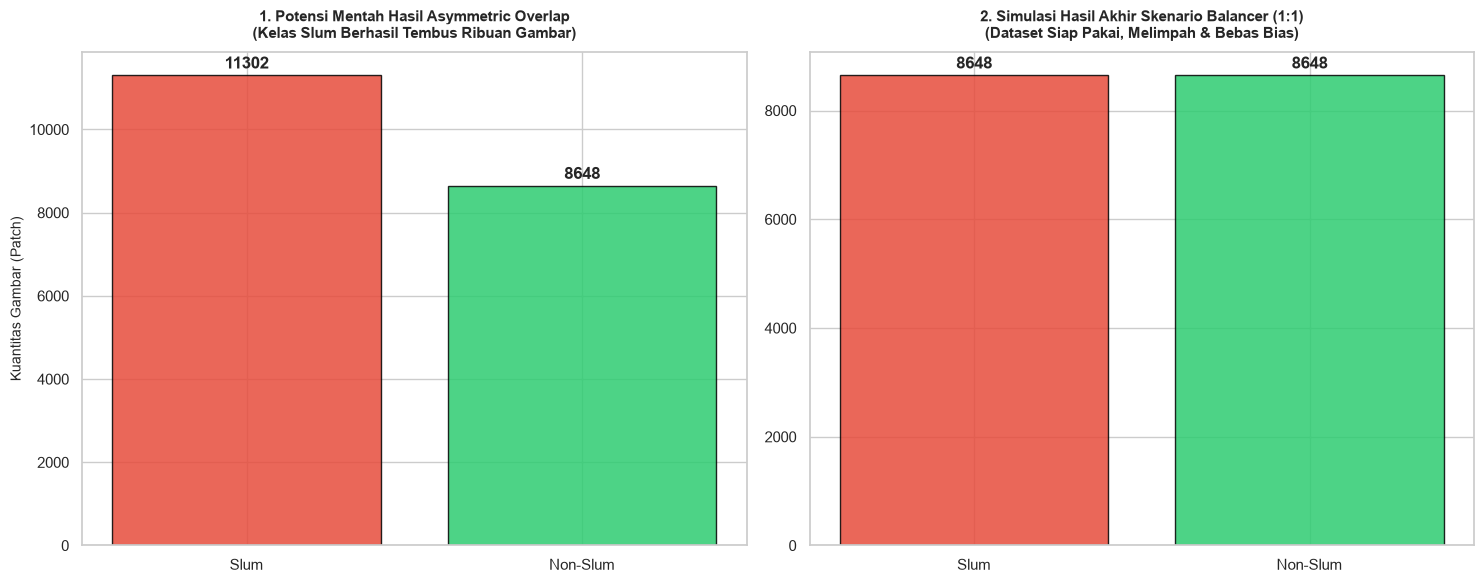

In [4]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
categories = ['Slum', 'Non-Slum']

# Grafik 1: Kondisi Mentah Setelah Ditopang Asymmetric Overlap
counts_raw = [total_slum, total_nonslum]
axes[0].bar(categories, counts_raw, color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[0].set_title("1. Potensi Mentah Hasil Asymmetric Overlap\n(Kelas Slum Berhasil Tembus Ribuan Gambar)", fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel("Kuantitas Gambar (Patch)", fontsize=10)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# Grafik 2: Kondisi Ideal Siap Masuk Arsitektur Model Deep Learning
counts_balanced = [target_balance, target_balance]
axes[1].bar(categories, counts_balanced, color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
axes[1].set_title("2. Simulasi Hasil Akhir Skenario Balancer (1:1)\n(Dataset Siap Pakai, Melimpah & Bebas Bias)", fontsize=11, fontweight='bold', pad=10)
for bar in axes[1].patches:
    axes[1].annotate(f'{int(bar.get_height())}', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()